All trial prototype drift shape: (10, 299, 10)


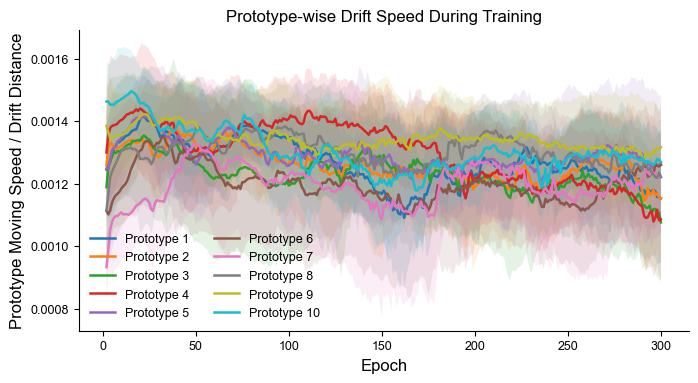

Figure saved to: ./SI_figs/prototype_speed_each_proto.svg
CSV saved to: ./SI_figs/prototype_speed_each_proto.csv


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 可调参数
# =========================
epochs = range(1, 301)
num_trials = 10
save_path = '/data/hwx/boron/new_proto_save'

width_cm = 18
height_cm = 10

save_fig = True
out_dir = "./SI_figs"
fig_path = os.path.join(out_dir, "prototype_speed_each_proto.svg")
csv_path = os.path.join(out_dir, "prototype_speed_each_proto.csv")
dpi = 600

# =========================
# 创建保存文件夹
# =========================
os.makedirs(out_dir, exist_ok=True)

# =========================
# 工具函数
# =========================
def cm_to_inch(cm):
    return cm / 2.54


# =========================
# 读取并计算每个 prototype 的 drift speed
# =========================
all_trial_proto_drifts = []

for trial in range(1, num_trials + 1):

    protos = []

    for e in epochs:
        p = torch.load(
            f"{save_path}/proto_trial_{trial}_epoch_{e}.pth",
            map_location="cpu"
        )

        p = p.detach().cpu().numpy()
        protos.append(p)

    protos = np.stack(protos)  
    # shape: [num_epochs, num_prototypes, embedding_dim]

    # epoch-wise prototype movement
    # shape: [num_epochs - 1, num_prototypes]
    proto_drift = np.linalg.norm(
        protos[1:] - protos[:-1],
        axis=2
    )

    all_trial_proto_drifts.append(proto_drift)

all_trial_proto_drifts = np.stack(all_trial_proto_drifts)
# shape: [num_trials, num_epochs - 1, num_prototypes]

print("All trial prototype drift shape:", all_trial_proto_drifts.shape)


# =========================
# 统计：10个trials平均与标准差
# =========================
mean_proto_drift = all_trial_proto_drifts.mean(axis=0)
std_proto_drift = all_trial_proto_drifts.std(axis=0)

# shape: [num_epochs - 1, num_prototypes]
num_prototypes = mean_proto_drift.shape[1]

epoch_axis = np.arange(2, len(epochs) + 1)


# =========================
# 字体设置
# =========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['svg.fonttype'] = 'none'


# =========================
# 画图
# =========================
fig, ax = plt.subplots(
    figsize=(cm_to_inch(width_cm), cm_to_inch(height_cm))
)

for p in range(num_prototypes):
    ax.plot(
        epoch_axis,
        mean_proto_drift[:, p],
        linewidth=1.8,
        label=f"Prototype {p + 1}"
    )

    ax.fill_between(
        epoch_axis,
        mean_proto_drift[:, p] - std_proto_drift[:, p],
        mean_proto_drift[:, p] + std_proto_drift[:, p],
        alpha=0.12
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Prototype Moving Speed / Drift Distance")
ax.set_title("Prototype-wise Drift Speed During Training")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=2
)

plt.tight_layout()


# =========================
# 保存图片
# =========================
if save_fig:
    plt.savefig(
        fig_path,
        dpi=dpi,
        bbox_inches="tight",
        transparent=True
    )

plt.show()


# =========================
# 保存数据
# =========================
df = pd.DataFrame({
    "epoch": epoch_axis
})

for p in range(num_prototypes):
    df[f"proto_{p + 1}_mean_speed"] = mean_proto_drift[:, p]
    df[f"proto_{p + 1}_std_speed"] = std_proto_drift[:, p]

df.to_csv(csv_path, index=False)

print(f"Figure saved to: {fig_path}")
print(f"CSV saved to: {csv_path}")

/tmp/ipykernel_121705/28687661.py:89: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  search_df = pd.read_csv(SEARCHING_SPACE_CSV)


Missing SMILES: 0
All SMARTS patterns compiled successfully.


[11:30:30] WARNING: not removing hydrogen atom without neighbors
[11:30:30] WARNING: not removing hydrogen atom without neighbors
[11:30:30] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not removing hydrogen atom without neighbors
[11:30:31] WARNING: not r

Invalid molecule number: 0

NP motif proportion (%):
     tetra-alkoxy borate  tri-alkoxy borate  boron_oxalate  BF3-like motif  \
NP1                 0.09              37.64           0.14            0.00   
NP2                 0.02               4.43           0.00            0.02   
NP3                 0.00               4.16           0.00            0.05   
NP4                 0.05               4.32           0.00            0.70   
NP5                 0.00               7.84           0.00            0.00   
NP6                 0.23              20.11           0.05            0.36   
NP7                 0.05               2.18           0.00            0.25   

     fluorinated alkoxy  C-B(OR)2 motif  pentafluorophenyl group  \
NP1                0.02            0.86                     0.00   
NP2                0.02            1.16                     0.00   
NP3                0.00            1.68                     0.00   
NP4                0.18            3.95           

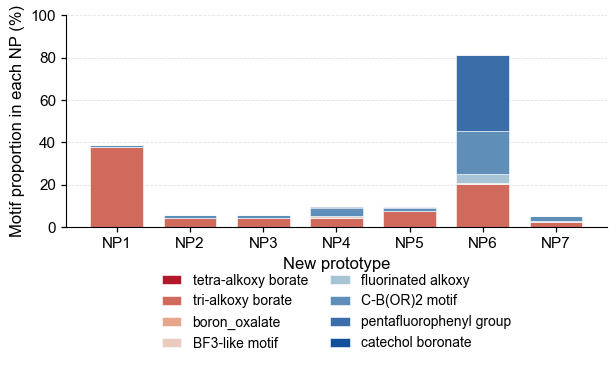


Saved SVG: ./SI_figs/NP_shared_motif_proportion.svg
Saved CSV: ./SI_figs/NP_shared_motif_proportion.csv


In [5]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem

# =========================================================
# 0. Paths
# =========================================================
SEARCHING_SPACE_CSV = "../data/searching_space_data_V2.csv"
RECOMMENDED_CSV = "../result_files_origin_backup/predicted_labels.csv"

OUT_DIR = "./SI_figs"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_SVG = os.path.join(OUT_DIR, "NP_shared_motif_proportion.svg")
OUT_CSV = os.path.join(OUT_DIR, "NP_shared_motif_proportion.csv")

# =========================================================
# 1. SMARTS patterns and colors
# =========================================================
SMARTS_PATTERNS = {
    "tetra-alkoxy borate": "[#5](-[#8])(-[#8])(-[#8])-[#8]",
    "tri-alkoxy borate": "[#5;D3;+0](-[#8])(-[#8])-[#8]",
    "boron_oxalate": "[#5]1[#8][#6](=[#8])[#6](=[#8])[#8]1",
    "BF3-like motif": "[#5](-[#9])(-[#9])-[#9]",
    "fluorinated alkoxy": "[#8]-[#6]-[#6](-[#9])(-[#9])-[#9]",
    "C-B(OR)2 motif": "[#6]-[#5;D3;+0](-[#8]-[#6])-[#8]-[#6]",
    "pentafluorophenyl group": "[c;D3]1[c]([#9])[c]([#9])[c]([#9])[c]([#9])[c]1[#9]",
    "catechol boronate": "[#5]1-[#8]-c2ccccc2-[#8]-1",
}

MOTIF_COLORS = {
    "tetra-alkoxy borate": "#B2182B",
    "tri-alkoxy borate": "#D06A5C",
    "boron_oxalate": "#E6A68B",
    "BF3-like motif": "#E9CABD",
    "fluorinated alkoxy": "#A8C4D4",
    "C-B(OR)2 motif": "#5F8FB8",
    "pentafluorophenyl group": "#3B6EA8",
    "catechol boronate": "#11519B",
}

motif_names = list(SMARTS_PATTERNS.keys())

# =========================================================
# 2. Helper functions
# =========================================================
def normalize_np_label(x):
    s = str(x).strip()
    if s.startswith("NP"):
        return s
    digits = "".join([c for c in s if c.isdigit()])
    if digits == "":
        return s
    return f"NP{int(digits)}"


def sort_np_labels(labels):
    return sorted(
        labels,
        key=lambda x: int("".join([c for c in str(x) if c.isdigit()]) or 999)
    )


def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def has_substructure(mol, patt):
    if mol is None or patt is None:
        return False
    try:
        return mol.HasSubstructMatch(patt)
    except Exception:
        return False


# =========================================================
# 3. Load data
# =========================================================
search_df = pd.read_csv(SEARCHING_SPACE_CSV)
rec_df = pd.read_csv(RECOMMENDED_CSV)

required_search_cols = ["cid", "SMILES"]
required_rec_cols = ["id", "label"]

for col in required_search_cols:
    if col not in search_df.columns:
        raise ValueError(f"searching_space_data_V2.csv 缺少必要列: {col}")

for col in required_rec_cols:
    if col not in rec_df.columns:
        raise ValueError(f"predicted_labels.csv 缺少必要列: {col}")

search_df["cid"] = search_df["cid"].astype(str)
rec_df["id"] = rec_df["id"].astype(str)

rec_df["NP"] = rec_df["label"].apply(normalize_np_label)

merged = rec_df.merge(
    search_df[["cid", "SMILES"]],
    left_on="id",
    right_on="cid",
    how="left"
)

missing_smiles = merged["SMILES"].isna().sum()
print("Missing SMILES:", missing_smiles)

if missing_smiles > 0:
    print(
        merged.loc[merged["SMILES"].isna(), ["id", "label"]].head(20)
    )

# =========================================================
# 4. Compile SMARTS
# =========================================================
compiled_patterns = {}

for motif_name, smarts in SMARTS_PATTERNS.items():
    patt = Chem.MolFromSmarts(smarts)
    if patt is None:
        raise ValueError(f"Invalid SMARTS: {motif_name} -> {smarts}")
    compiled_patterns[motif_name] = patt

print("All SMARTS patterns compiled successfully.")

# =========================================================
# 5. SMARTS matching
# =========================================================
merged["mol"] = merged["SMILES"].apply(smiles_to_mol)
merged["valid_mol"] = merged["mol"].apply(lambda x: x is not None)

print("Invalid molecule number:", (~merged["valid_mol"]).sum())

for motif_name, patt in compiled_patterns.items():
    merged[f"hit__{motif_name}"] = merged["mol"].apply(
        lambda mol: has_substructure(mol, patt)
    )

# =========================================================
# 6. Calculate motif proportion in each NP
# =========================================================
new_protos = sort_np_labels(merged["NP"].dropna().unique())

prop_df = pd.DataFrame(
    0.0,
    index=new_protos,
    columns=motif_names
)

count_df = pd.DataFrame(
    0,
    index=new_protos,
    columns=motif_names
)

for np_id in new_protos:
    sub = merged[merged["NP"] == np_id].copy()
    n_total = len(sub)

    if n_total == 0:
        continue

    for motif in motif_names:
        hit_col = f"hit__{motif}"
        n_hit = int(sub[hit_col].sum())

        count_df.loc[np_id, motif] = n_hit
        prop_df.loc[np_id, motif] = n_hit / n_total * 100

prop_df.to_csv(OUT_CSV)

print("\nNP motif proportion (%):")
print(prop_df.round(2))

# =========================================================
# 7. Plot stacked bar chart for SI
# =========================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

# SI图不用太小，优先保证清晰
width_cm = 16
height_cm = 10
cm = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(width_cm * cm, height_cm * cm)
)

bottom = np.zeros(len(prop_df))
x = np.arange(len(prop_df.index))

for motif in motif_names:
    values = prop_df[motif].values

    ax.bar(
        x,
        values,
        bottom=bottom,
        color=MOTIF_COLORS[motif],
        edgecolor="white",
        linewidth=0.4,
        width=0.72,
        label=motif
    )

    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(prop_df.index)

ax.set_ylabel("Motif proportion in each NP (%)")
ax.set_xlabel("New prototype")

ax.set_ylim(0, max(100, bottom.max() * 1.12))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", length=3.5, width=0.9)

# 加淡网格，SI里更方便读数
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

# legend放到底部，避免挤压图主体
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16),
    ncol=2,
    handlelength=1.4,
    columnspacing=1.6
)

plt.tight_layout()

fig.savefig(
    OUT_SVG,
    format="svg",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)

plt.show()

print("\nSaved SVG:", OUT_SVG)
print("Saved CSV:", OUT_CSV)